# 離散監視バリア：微分教師とDML

保存済みpilot・全学習seed・独立数値参照・Hermite比較を読む研究教材です。
結果の表示と軽い配列集計だけを実行し、金融教師、学習、ネット接続、GPU検出を呼び出しません。
pilotの大きな生パス配列は開きません。smoke/fixtureは性能結論に使えません。

In [1]:
import json
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

# Override an inherited Agg backend so headless execution retains inline PNGs.
get_ipython().run_line_magic("matplotlib", "inline")

def resolve_artifacts():
    supplied = os.environ.get("JOHNHULL_BARRIER_DML_ARTIFACT_DIR")
    candidates = [Path(supplied)] if supplied else [Path(".")]
    if not supplied:
        candidates += [parent / "johnhull/research/RB-F05/discrete"
                       for parent in [Path.cwd(), *Path.cwd().parents]]
    for candidate in candidates:
        if all((candidate / name).is_file() for name in ("reference.json", "pilot.json", "reference.npz")):
            return candidate
    raise FileNotFoundError("Saved barrier artifacts unavailable; set JOHNHULL_BARRIER_DML_ARTIFACT_DIR.")

artifact_dir = resolve_artifacts()
record = json.loads((artifact_dir / "reference.json").read_text())
pilot = json.loads((artifact_dir / "pilot.json").read_text())
# Load only display arrays; neither pilot raw paths nor main training paths.
with np.load(artifact_dir / "reference.npz", allow_pickle=False) as source:
    keys = [key for key in source.files if key in {"test.inputs", "test.reference", "model_ids",
             "diagnostic.inputs", "diagnostic.reference", "boundary.inputs", "boundary.reference"}
            or (key.startswith("prediction.") and key.endswith((".test", ".safe")))
            or (key.startswith("routing.") and key.endswith(".safe"))]
    arrays = {key: source[key] for key in keys}
seeds = record["protocol"]["learning"]["seeds"]
nn_ids = [f"{mode}_s{seed}" for mode in ("price", "dml") for seed in seeds]
methods = nn_ids + ["hermite", "oracle"]
test_inputs, target = arrays["test.inputs"], arrays["test.reference"]
predictions = {identifier: arrays[f"prediction.{identifier}.test"] for identifier in nn_ids+["hermite"]}
def rmse(value):
    error = np.asarray(value)-target
    if error.shape != target.shape or not np.isfinite(error).all():
        return None
    return np.sqrt(np.mean(error**2, axis=0))
accuracy = {identifier: rmse(value) for identifier, value in predictions.items()}
accuracy["oracle"] = rmse(arrays.get("prediction.oracle.test", target))
safe_accuracy = {identifier: rmse(arrays[f"prediction.{identifier}.safe"])
                 for identifier in methods if f"prediction.{identifier}.safe" in arrays}
labels = {identifier: identifier.replace("_s", "\ns") for identifier in nn_ids}
labels.update(hermite="Hermite", oracle="GL oracle")
colors = {identifier: "tab:blue" if identifier.startswith("price") else "tab:orange" for identifier in nn_ids}
colors.update(hermite="black", oracle="gray")
styles = {seed: style for seed, style in zip(seeds, ["-", "--", ":"], strict=True)}
def style(identifier):
    return styles[int(identifier.split("_s")[-1])] if identifier in nn_ids else "-."
plt.rcParams.update({"figure.dpi": 110, "font.size": 9, "axes.grid": False})
mode = record.get("mode", record.get("experiment", "unknown"))
status = "Main synthetic experiment" if mode == "main" else "SMOKE / fixture only: not a financial performance conclusion"
if any(row.get("budget_failure", False) for row in record["models"].values()):
    status += "; incomplete fits"
print(status)
print("Saved JSON summaries and compact arrays only; no pricing, training or pilot raw paths.")
display(Markdown("契約はK100・H120、無rebate、時点0と12回の正時点監視です。接触S≥HでKO。spotを動かしてもK/H/T/mは固定します。このnotebookは表示用です。数値監査はpilot/build_referenceのcheckを別途実行してください。"))


Main synthetic experiment
Saved JSON summaries and compact arrays only; no pricing, training or pilot raw paths.


契約はK100・H120、無rebate、時点0と12回の正時点監視です。接触S≥HでKO。spotを動かしてもK/H/T/mは固定します。このnotebookは表示用です。数値監査はpilot/build_referenceのcheckを別途実行してください。

## 1. 教師と独立参照の誤差を分ける

pilot JSONの各価格・Delta教師のmean±6 IID SEを表示。raw LRM、最終増分の条件付け、OSS、PW負対照を区別します。
GL/PDEの空間・時間・独立差は別パネルです。6SEの範囲内でも不偏性の証明にはなりません。

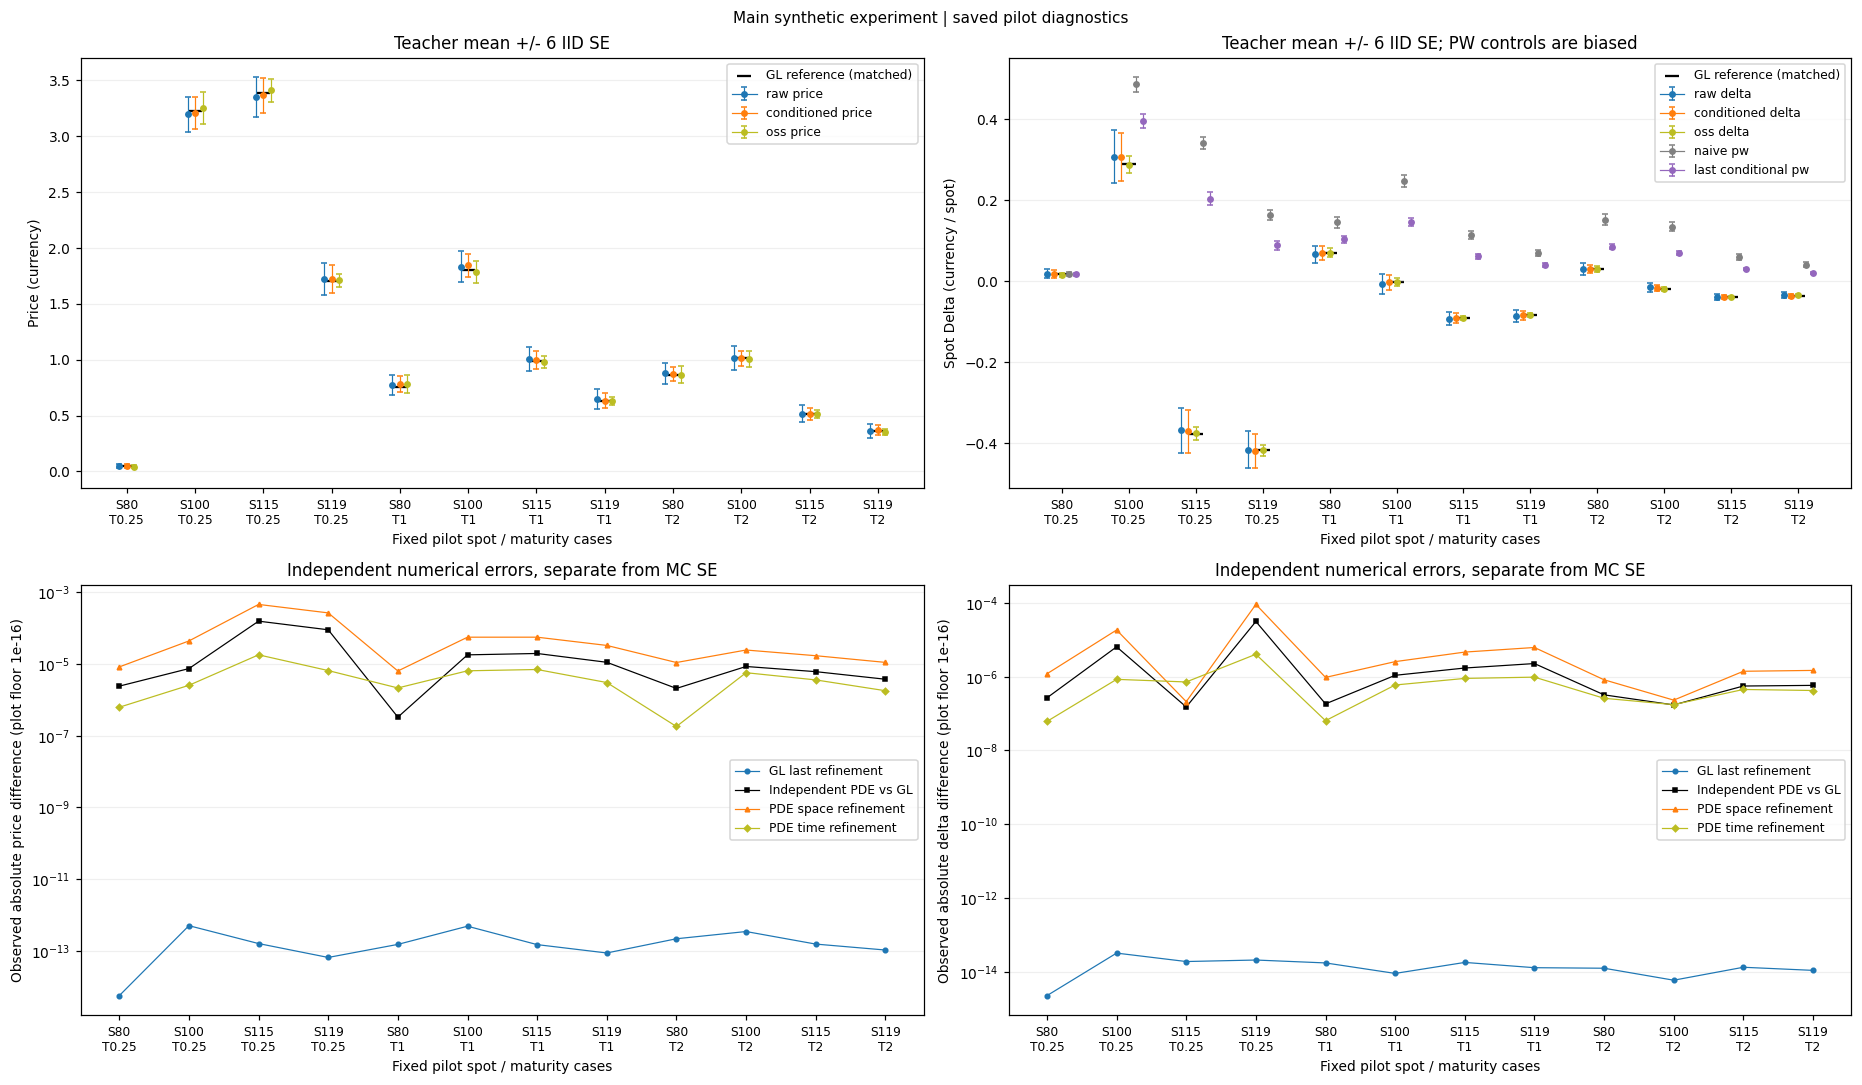

6 SE bars are IID sampling diagnostics, not a confidence certification or proof of unbiasedness.
GL/PDE refinement differences are observed numerical differences; their scope differs from MC sampling error.
m=1 density/CDF independent differences: {'max_price_difference': 3.108624468950438e-14, 'max_delta_difference': 1.969939211754479e-10, 'max_bump_difference': 6.608047442568932e-10, 'naive_pw_missing_boundary_term': [0.00029480639094630126, 0.15722443580189388, 0.6355325752707395, 0.6643365021839926, 0.06851496238911096, 0.26710257457939807, 0.3322219259515714, 0.32532678063124004, 0.13120234791014526, 0.22533008165541116, 0.23028101370577422, 0.2230607683781946]}
Frequency PW controls: {'naive_pw': {'status': 'biased_control', 'outside_six_se_count': 8, 'case_count': 8}, 'last_conditional_pw': {'status': 'biased_control', 'outside_six_se_count': 6, 'case_count': 6}}


In [2]:
cases = pilot["summary"]["mc"]["cases"]
convergence = pilot["summary"]["convergence"]
positions = np.arange(len(cases))
case_labels = [f"S{row['spot']:g}\nT{row['maturity']:g}" for row in cases]
fig, axes = plt.subplots(2, 2, figsize=(17, 10))
teacher_groups = [(axes[0, 0], ["raw_price", "conditioned_price", "oss_price"], "Price (currency)"),
                  (axes[0, 1], ["raw_delta", "conditioned_delta", "oss_delta", "naive_pw", "last_conditional_pw"], "Spot Delta (currency / spot)")]
teacher_colors = ["tab:blue", "tab:orange", "tab:olive", "gray", "tab:purple"]
for ax, teacher_names, ylabel in teacher_groups:
    for index, name in enumerate(teacher_names):
        for row, case in enumerate(cases):
            estimate = case["methods"][name]
            if estimate.get("mean") is None:
                continue
            se = estimate.get("se")
            offset = (index-(len(teacher_names)-1)/2)*.11
            ax.errorbar(row+offset, estimate["mean"], yerr=None if se is None else 6*se,
                        color=teacher_colors[index], marker="x" if se is None else "o",
                        markersize=3.5, capsize=2, linewidth=.8,
                        label=name.replace("_", " ") if row == 0 else None)
    # Absolute GL levels are joined only where compact main diagnostics match.
    if "diagnostic.inputs" in arrays and "diagnostic.reference" in arrays:
        matched_any = False
        for row, case in enumerate(cases):
            requested = [case["spot"], case["maturity"], case["monitoring"]]
            match = np.flatnonzero(np.all(np.isclose(arrays["diagnostic.inputs"], requested), axis=1))
            if len(match):
                coordinate = 0 if ylabel.startswith("Price") else 1
                ax.scatter(row, arrays["diagnostic.reference"][match[0], coordinate], marker="_", s=90, color="black",
                           label="GL reference (matched)" if not matched_any else None)
                matched_any = True
    ax.set_ylabel(ylabel)
    ax.set_title("Teacher mean +/- 6 IID SE" + ("; PW controls are biased" if len(teacher_names) > 3 else ""))
    ax.legend(fontsize=8, loc="best")
    ax.grid(axis="y", alpha=.2)
for coordinate, ax in zip(("price", "delta"), axes[1], strict=True):
    series = {"GL last refinement": [], "Independent PDE vs GL": [], "PDE space refinement": [], "PDE time refinement": []}
    for row in convergence:
        series["GL last refinement"].append(row["gl_adjacent"][-1][coordinate] if row["gl_adjacent"] else np.nan)
        series["Independent PDE vs GL"].append(row["independent_pde_vs_gl"][coordinate])
        for group in ("space", "time"):
            values = row["pde_groups"].get(group, [])
            series[f"PDE {group} refinement"].append(values[-1][coordinate] if values else np.nan)
    for (name, values), color, marker in zip(series.items(), ["tab:blue", "black", "tab:orange", "tab:olive"], ["o", "s", "^", "D"], strict=True):
        ax.plot(np.arange(len(values)), np.maximum(values, 1e-16), color=color, marker=marker, markersize=3, linewidth=.8, label=name)
    ax.set_yscale("log")
    ax.set_ylabel(f"Observed absolute {coordinate} difference (plot floor 1e-16)")
    ax.set_title("Independent numerical errors, separate from MC SE")
    ax.legend(fontsize=8)
    ax.grid(axis="y", alpha=.2)
for ax in axes.ravel():
    ax.set_xticks(positions, case_labels, fontsize=8)
    ax.set_xlabel("Fixed pilot spot / maturity cases")
fig.suptitle(status + " | saved pilot diagnostics", fontsize=10)
fig.tight_layout()
plt.show()
plt.close(fig)
print("6 SE bars are IID sampling diagnostics, not a confidence certification or proof of unbiasedness.")
print("GL/PDE refinement differences are observed numerical differences; their scope differs from MC sampling error.")
print("m=1 density/CDF independent differences:", pilot["summary"].get("m1", {}))
print("Frequency PW controls:", pilot["summary"].get("frequency", {}).get("negative_controls", {}))


## 2. 全seedの価格・spot Deltaと境界

保存したtest配列から全6 NNとHermiteのRMSEを再計算します。価格と同じ補間器の導関数を比較します。
負のDeltaを許し、S<Hの価格をHで0へ強制しません。H接触の通常のDeltaは未定義です。

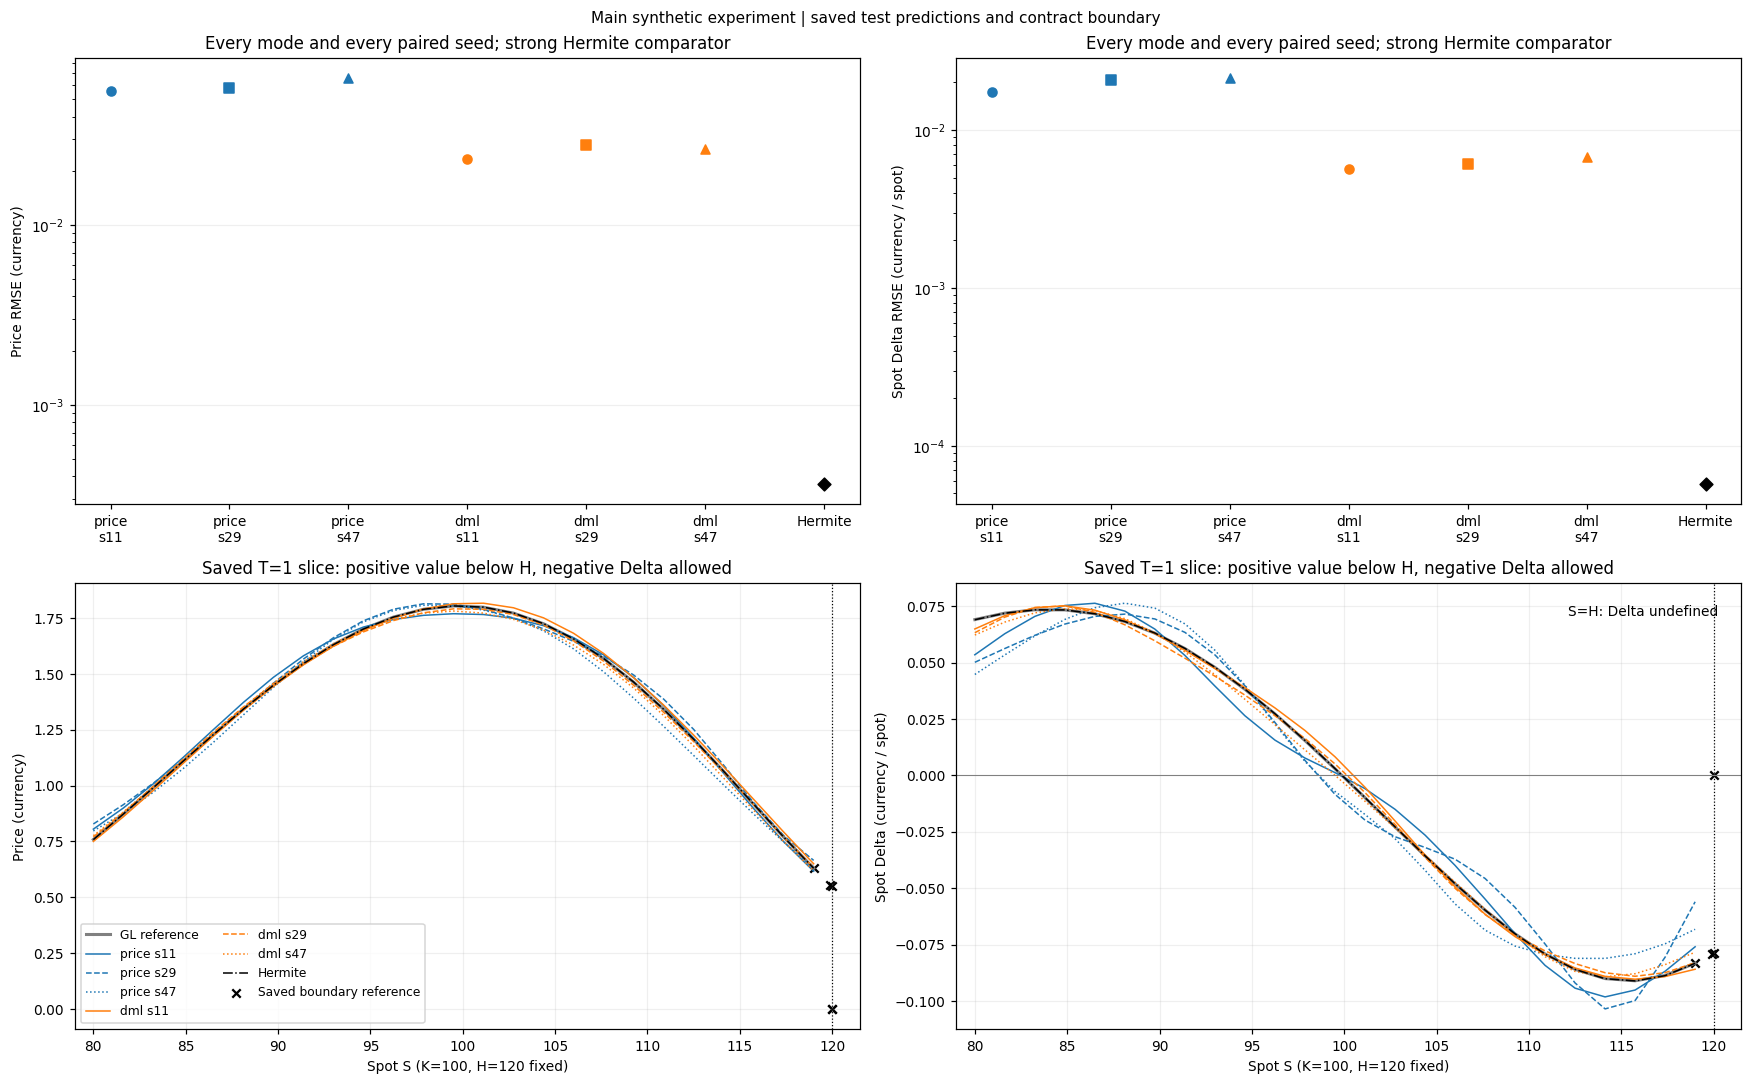

Hermite uses the derivative of the same interpolated price; all six NN seeds are retained.
At S=H, initial KO gives price zero and ordinary Delta undefined. The living-side price is not constrained to zero.


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
display_methods = nn_ids + ["hermite"]
for coordinate, ax in enumerate(axes[0]):
    for position, identifier in enumerate(display_methods):
        value = accuracy[identifier]
        if value is not None:
            ax.scatter(position, max(value[coordinate], 1e-14), color=colors[identifier],
                       marker="D" if identifier == "hermite" else ["o", "s", "^"][seeds.index(int(identifier.split("_s")[-1]))], s=35)
    ax.set_xticks(range(len(display_methods)), [labels[name] for name in display_methods])
    ax.set_yscale("log")
    ax.set_ylabel("Price RMSE (currency)" if coordinate == 0 else "Spot Delta RMSE (currency / spot)")
    ax.set_title("Every mode and every paired seed; strong Hermite comparator")
    ax.grid(axis="y", alpha=.2)
time = min(np.unique(test_inputs[:, 1]), key=lambda value: abs(np.log(value)))
selected = np.flatnonzero(np.isclose(test_inputs[:, 1], time))
selected = selected[np.argsort(test_inputs[selected, 0])]
for coordinate, ax in enumerate(axes[1]):
    ax.plot(test_inputs[selected, 0], target[selected, coordinate], color="gray", linewidth=2, label="GL reference")
    for identifier in display_methods:
        ax.plot(test_inputs[selected, 0], predictions[identifier][selected, coordinate],
                color=colors[identifier], linestyle=style(identifier), linewidth=1, label=labels[identifier].replace("\n", " "))
    if "boundary.inputs" in arrays and "boundary.reference" in arrays:
        boundary = arrays["boundary.inputs"]
        mask = np.isclose(boundary[:, 1], time)
        ax.scatter(boundary[mask, 0], arrays["boundary.reference"][mask, coordinate], color="black", marker="x", s=30, label="Saved boundary reference")
    ax.axvline(120, color="black", linestyle=":", linewidth=.8)
    ax.set_xlabel("Spot S (K=100, H=120 fixed)")
    ax.set_ylabel("Price (currency)" if coordinate == 0 else "Spot Delta (currency / spot)")
    ax.set_title(f"Saved T={time:g} slice: positive value below H, negative Delta allowed")
    ax.grid(alpha=.2)
    ax.set_xlim(min(test_inputs[selected, 0])-1, 121.5)
axes[1, 0].legend(fontsize=8, ncol=2)
axes[1, 1].axhline(0, color="gray", linewidth=.7)
axes[1, 1].text(.97, .95, "S=H: Delta undefined", ha="right", va="top", transform=axes[1, 1].transAxes)
fig.suptitle(status + " | saved test predictions and contract boundary", fontsize=10)
fig.tight_layout()
plt.show()
plt.close(fig)
print("Hermite uses the derivative of the same interpolated price; all six NN seeds are retained.")
print("At S=H, initial KO gives price zero and ordinary Delta undefined. The living-side price is not constrained to zero.")
if "boundary.reference" not in arrays:
    print("Fine boundary reference not saved; S=119 is a saved interior observation, not an extrapolated H limit.")


## 3. raw/safe、精度と総費用

価格＋spot Deltaを全batchで測定したmedian/p95を表示。safeは入力・領域・価格範囲確認とfallbackを含み、oracleにも同じwrapperを使います。
総費用は教師生成・fit/export・測定済みload＋全batch呼出費用です。safe精度は保存safe配列だけから集計し、raw精度を流用しません。
p95成分の和は総時間のp95実測ではありません。欠損計時・safe出力・loadは欠損として表示します。

Latency retained; no cost recovery comparison for unsupported price+ordinary Delta batches: safe/batch32: delta_undefined
C(N_calls) uses full batch calls; query budgets require ceil(N_queries/batch), never fractional calls.
Strong Hermite and GL oracle are included; unsupported batches retain latency only and are excluded from successful accuracy/cost comparisons.
p95 shading is a sum-of-components scenario, not measured total p95 or a confidence interval.
Deployment includes one warm-cache whole research bundle load; cold I/O, process/import and minimal packaging remain outside this measurement.


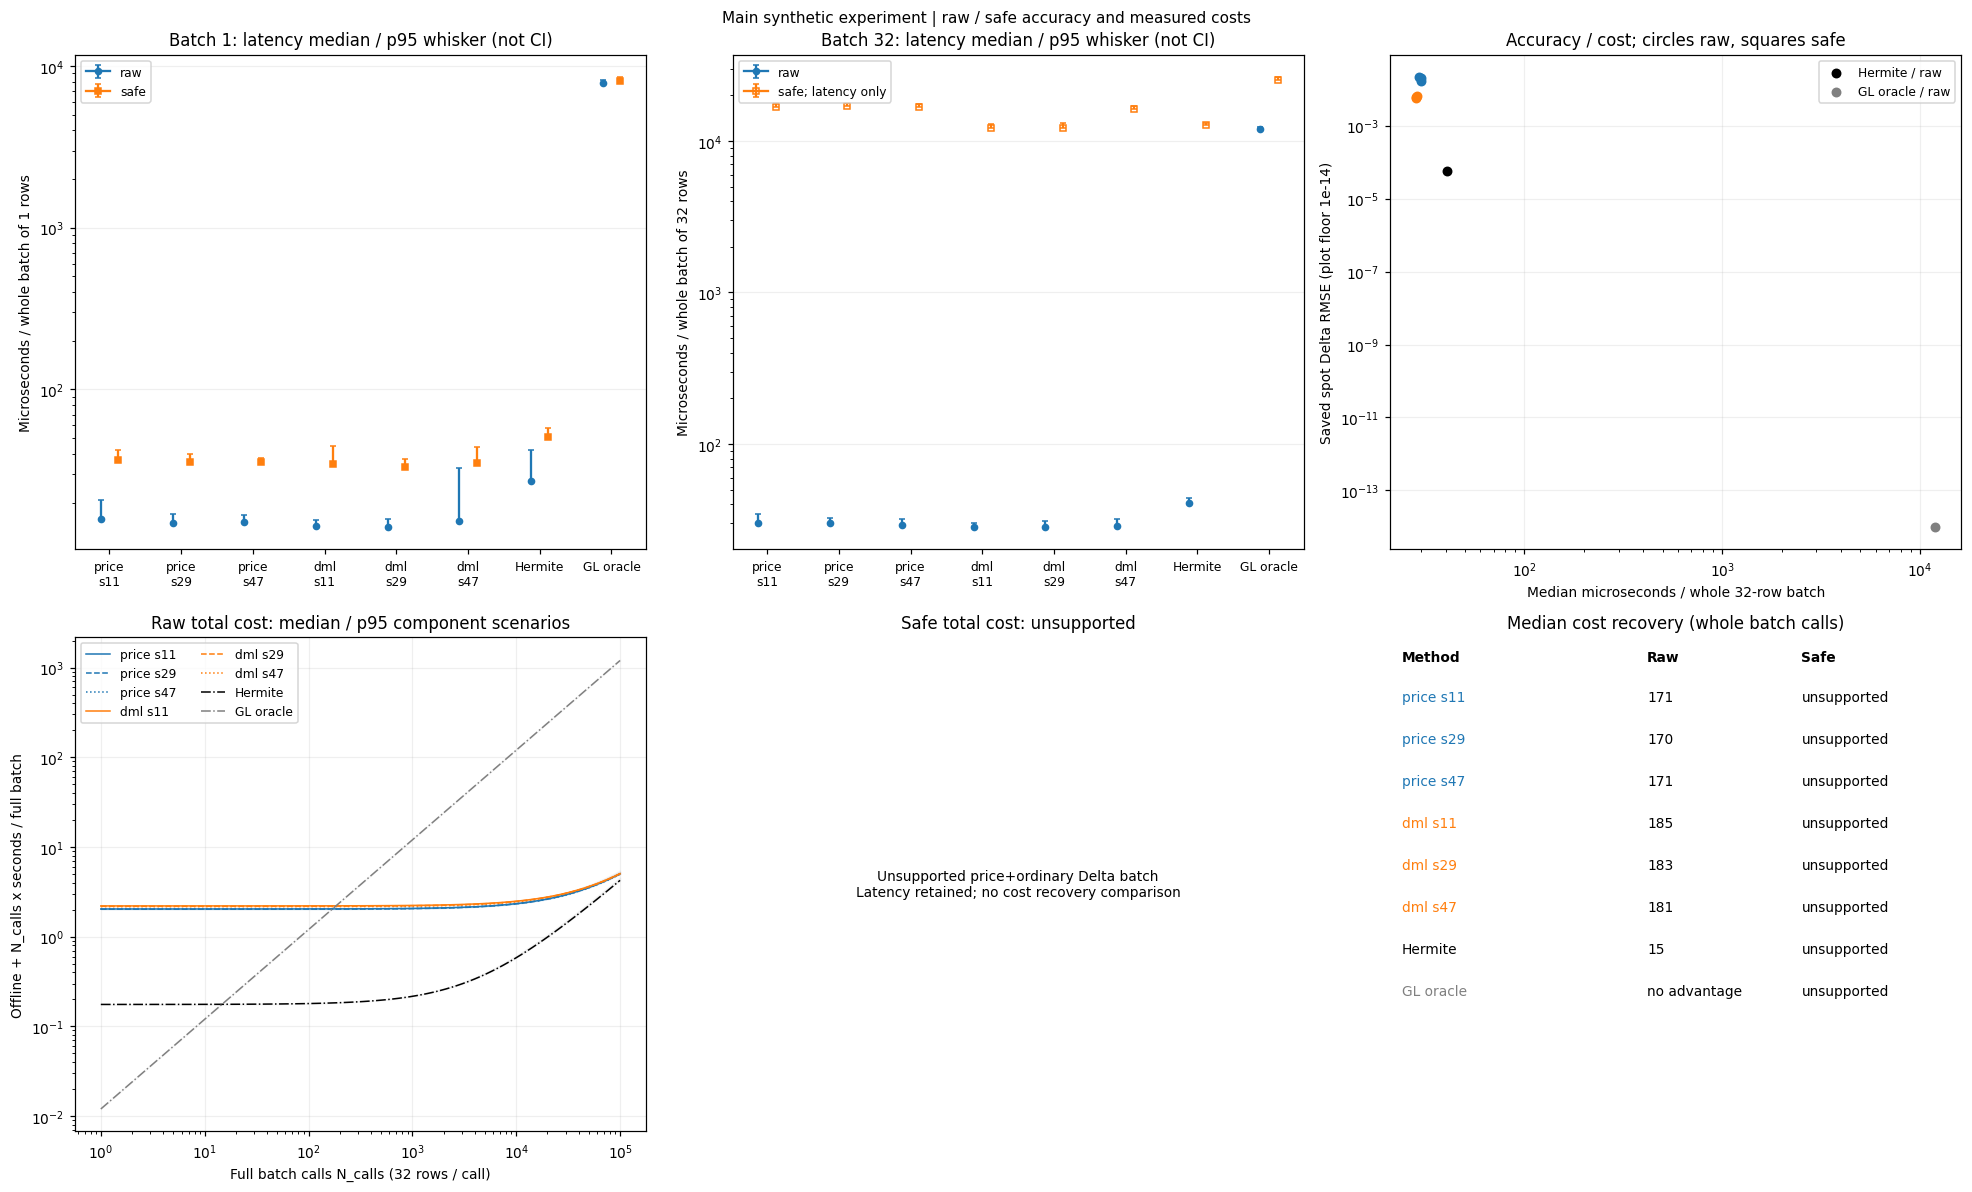

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
measurements = record.get("benchmark", {}).get("measurements", [])
comparisons = record.get("costs", {}).get("comparisons", [])
if not measurements or not comparisons:
    for ax in axes.ravel():
        ax.text(.5, .5, "Not measured\nTiming / cost comparison incomplete", ha="center", va="center", transform=ax.transAxes)
        ax.set_axis_off()
    print("Not measured: timing/cost evidence unavailable; no performance conclusion.")
else:
    unsupported_rows = [row for row in measurements if row.get("comparison_status") == "unsupported"]
    if unsupported_rows:
        reasons = sorted({f"{row['phase']}/batch{row['batch_size']}: "+", ".join(row.get("unsupported_reasons", []))
                          for row in unsupported_rows})
        print("Latency retained; no cost recovery comparison for unsupported price+ordinary Delta batches: " + "; ".join(reasons))
    for batch, ax in zip((1, 32), axes[0, :2], strict=True):
        for phase, offset, color, marker in [("raw", -.12, "tab:blue", "o"), ("safe", .12, "tab:orange", "s")]:
            for position, identifier in enumerate(methods):
                row = next(item for item in measurements if item["method_id"] == identifier and item["phase"] == phase and item["batch_size"] == batch)
                median, p95 = row["median_s"]*1e6, row["p95_s"]*1e6
                supported = row.get("comparison_status", "supported") == "supported"
                ax.errorbar(position+offset, median, yerr=[[0], [max(0, p95-median)]], color=color, marker=marker,
                            markerfacecolor=color if supported else "none", capsize=2, markersize=4,
                            label=phase+("; latency only" if not supported else "") if position == 0 else None)
        ax.set_xticks(range(len(methods)), [labels[name] for name in methods], fontsize=8)
        ax.set_yscale("log")
        ax.set_ylabel(f"Microseconds / whole batch of {batch} rows")
        ax.set_title(f"Batch {batch}: latency median / p95 whisker (not CI)")
        ax.legend(fontsize=8)
        ax.grid(axis="y", alpha=.2)
    missing_safe = []
    for identifier in methods:
        for phase, marker in [("raw", "o"), ("safe", "s")]:
            error = accuracy[identifier] if phase == "raw" else safe_accuracy.get(identifier)
            if error is None:
                if phase == "safe":
                    missing_safe.append(identifier)
                continue
            row = next(item for item in measurements if item["method_id"] == identifier and item["phase"] == phase and item["batch_size"] == 32)
            if row.get("comparison_status") == "unsupported":
                continue
            axes[0, 2].scatter(row["median_s"]*1e6, max(error[1], 1e-14), color=colors[identifier], marker=marker, s=30,
                               label=labels[identifier]+" / "+phase if identifier in ("hermite", "oracle") else None)
    axes[0, 2].set_xscale("log")
    axes[0, 2].set_yscale("log")
    axes[0, 2].set_xlabel("Median microseconds / whole 32-row batch")
    axes[0, 2].set_ylabel("Saved spot Delta RMSE (plot floor 1e-14)")
    axes[0, 2].set_title("Accuracy / cost; circles raw, squares safe")
    axes[0, 2].legend(fontsize=8, loc="best")
    axes[0, 2].grid(alpha=.2)
    if missing_safe:
        print("Safe accuracy not saved or nonfinite: " + ", ".join(missing_safe))
    call_counts = np.unique(np.ceil(np.logspace(0, 5, 90)).astype(int))
    training_only = False
    recoveries = {}
    for phase, ax in zip(("raw", "safe"), axes[1, :2], strict=True):
        plotted = 0
        for identifier in methods:
            row = next(item for item in comparisons if item["method_id"] == identifier and item["phase"] == phase and item["batch_size"] == 32)
            median, p95 = row["statistics"]["median"], row["statistics"]["p95"]
            if row.get("comparison_status") == "unsupported" or median["training_only"] is None or p95["training_only"] is None:
                recoveries[identifier, phase] = "unsupported"
                continue
            complete = median["deployment"] is not None and p95["deployment"] is not None
            mcost = median["deployment"] if complete else median["training_only"]
            pcost = p95["deployment"] if complete else p95["training_only"]
            training_only = training_only or not complete
            lower = mcost["offline_s"]+call_counts*median["surrogate_online_s_per_batch"]
            upper = pcost["offline_s"]+call_counts*p95["surrogate_online_s_per_batch"]
            ax.plot(call_counts, lower, color=colors[identifier], linestyle=style(identifier), linewidth=1, label=labels[identifier].replace("\n", " "))
            ax.fill_between(call_counts, lower, upper, color=colors[identifier], alpha=.035)
            recovery = mcost["break_even"]
            recoveries[identifier, phase] = str(recovery["first_integer_call"]) if recovery["first_integer_call"] is not None else "no advantage"
            plotted += 1
        if not plotted:
            ax.text(.5, .5, "Unsupported price+ordinary Delta batch\nLatency retained; no cost recovery comparison",
                    ha="center", va="center", transform=ax.transAxes)
            ax.set_title(phase.capitalize()+" total cost: unsupported")
            ax.set_axis_off()
            continue
        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlabel("Full batch calls N_calls (32 rows / call)")
        ax.set_ylabel("Offline + N_calls x seconds / full batch")
        ax.set_title(phase.capitalize()+" total cost: median / p95 component scenarios")
        ax.legend(fontsize=8, ncol=2)
        ax.grid(alpha=.2)
    axes[1, 2].set_axis_off()
    axes[1, 2].set_title("Median cost recovery (whole batch calls)")
    axes[1, 2].text(.02, .95, "Method", weight="bold")
    axes[1, 2].text(.45, .95, "Raw", weight="bold")
    axes[1, 2].text(.72, .95, "Safe", weight="bold")
    for position, identifier in enumerate(methods):
        y = .87-position*.085
        axes[1, 2].text(.02, y, labels[identifier].replace("\n", " "), color=colors[identifier])
        axes[1, 2].text(.45, y, recoveries[identifier, "raw"])
        axes[1, 2].text(.72, y, recoveries[identifier, "safe"])
    print("C(N_calls) uses full batch calls; query budgets require ceil(N_queries/batch), never fractional calls.")
    print("Strong Hermite and GL oracle are included; unsupported batches retain latency only and are excluded from successful accuracy/cost comparisons.")
    print("p95 shading is a sum-of-components scenario, not measured total p95 or a confidence interval.")
    if training_only:
        print("Loading not measured: some curves show training-only costs, not complete deployment.")
    else:
        print("Deployment includes one warm-cache whole research bundle load; cold I/O, process/import and minimal packaging remain outside this measurement.")
fig.suptitle(status + " | raw / safe accuracy and measured costs", fontsize=10)
fig.tight_layout()
plt.show()
plt.close(fig)


## 制限と次の判断

合成GBM・固定の離散監視契約です。連続監視、実市場、0DTE、roughモデル、動的ヘッジへ性能を外挿しません。
研究の完了と標準採用を分け、全seedの精度、強い補間対照、入力判断とfallback、測定境界を確認して採否を記録します。